# Notebook 10 — Multi-Class Damage Detector (dacl10k)

Fine-tunes a YOLOv8s detector on the **dacl10k** bridge inspection dataset, filtered to 5 heritage-relevant damage classes.

| Class | dacl10k source | Heritage analogue |
|-------|---------------|-------------------|
| `crack` | Crack + ACrack | structural cracks |
| `efflorescence` | Efflorescence | salt deposits, stage 3 |
| `spalling` | Spalling | surface material loss, erosion |
| `weathering` | Weathering | colour aging, staining |
| `wetspot` | Wetspot | biological growth proxy |

**Runtime:** `Runtime > Change runtime type > T4 GPU`

In [1]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path

DRIVE_DIR = Path('/content/drive/MyDrive/HeritagePreservation')
DATA_DIR  = Path('/content/data')
CKPT_DIR  = Path('/content/checkpoints/dacl10k_detector')
OUT_DIR   = Path('/content/outputs/dacl10k_detector')

for d in [DATA_DIR, CKPT_DIR, OUT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print('Drive contents:')
print(sorted(f.name for f in DRIVE_DIR.iterdir()) if DRIVE_DIR.exists() else 'DRIVE_DIR not found')

Mounted at /content/drive
Drive contents:
['checkpoints', 'crackforest.zip', 'cross_eval', 'degradation_analysis', 'failure_analysis', 'historical_crack.zip', 'masonry.zip', 'notebooks', 'omnicrack30k.zip', 'plots', 'samples']


In [2]:
!pip install -q ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 39.4 MB/s eta 0:00:00


## 1. Download & Prepare dacl10k

In [3]:
import subprocess, zipfile

DACL_ZIP = DATA_DIR / 'dacl10k_v2_devphase.zip'
DACL_DIR = DATA_DIR / 'dacl10k_v2_devphase'

if DACL_DIR.exists() and any(DACL_DIR.rglob('*.jpg')):
    print('dacl10k already extracted')
else:
    print('Downloading dacl10k from AWS S3 (~4.8 GB)...')
    subprocess.run([
        'wget', '-q', '--show-progress',
        'https://dacl10k.s3.eu-central-1.amazonaws.com/dacl10k-challenge/dacl10k_v2_devphase.zip',
        '-O', str(DACL_ZIP)
    ], check=True)
    print('Extracting...')
    with zipfile.ZipFile(DACL_ZIP) as zf:
        zf.extractall(DATA_DIR)
    print('Done')

Extracting...
Done


In [4]:
import json, shutil
from pathlib import Path

DACL_ROOT = DATA_DIR / 'dacl10k_v2_devphase'
YOLO_DIR  = DATA_DIR / 'dacl10k_yolo'

KEEP_CLASSES = {
    'Crack':         0,
    'ACrack':        0,
    'Efflorescence': 1,
    'Spalling':      2,
    'Weathering':    3,
    'Wetspot':       4,
}
CLASS_NAMES = ['crack', 'efflorescence', 'spalling', 'weathering', 'wetspot']
SPLIT_MAP   = {'train': 'train', 'validation': 'val'}


def polygon_to_bbox(points, img_w, img_h):
    xs = [p[0] for p in points]
    ys = [p[1] for p in points]
    x1, x2 = max(0, min(xs)), min(img_w, max(xs))
    y1, y2 = max(0, min(ys)), min(img_h, max(ys))
    cx = (x1 + x2) / 2 / img_w
    cy = (y1 + y2) / 2 / img_h
    w  = (x2 - x1) / img_w
    h  = (y2 - y1) / img_h
    return cx, cy, w, h


if (YOLO_DIR / 'data.yaml').exists():
    print('dacl10k_yolo already converted')
else:
    for dacl_split, out_split in SPLIT_MAP.items():
        ann_dir = DACL_ROOT / 'annotations' / dacl_split
        img_dir = DACL_ROOT / 'images' / dacl_split
        out_img = YOLO_DIR / 'images' / out_split
        out_lbl = YOLO_DIR / 'labels' / out_split
        out_img.mkdir(parents=True, exist_ok=True)
        out_lbl.mkdir(parents=True, exist_ok=True)

        n_imgs = n_boxes = 0
        for ann_path in sorted(ann_dir.glob('*.json')):
            ann    = json.loads(ann_path.read_text())
            img_w  = ann['imageWidth']
            img_h  = ann['imageHeight']
            img_name = ann['imageName']
            lines = []
            for shape in ann['shapes']:
                label = shape['label']
                if label not in KEEP_CLASSES:
                    continue
                cx, cy, w, h = polygon_to_bbox(shape['points'], img_w, img_h)
                if w < 0.001 or h < 0.001:
                    continue
                lines.append(f"{KEEP_CLASSES[label]} {cx:.6f} {cy:.6f} {w:.6f} {h:.6f}")
            src_img = img_dir / img_name
            if not src_img.exists():
                continue
            (out_lbl / ann_path.with_suffix('.txt').name).write_text('\n'.join(lines))
            shutil.copy2(src_img, out_img / img_name)
            n_imgs += 1
            n_boxes += len(lines)
        print(f'{out_split}: {n_imgs} images, {n_boxes} boxes')

    (YOLO_DIR / 'data.yaml').write_text(
        f"path: {YOLO_DIR}\ntrain: images/train\nval:   images/val\n"
        f"nc: {len(CLASS_NAMES)}\nnames: {CLASS_NAMES}\n"
    )
    print('data.yaml written')

train: 6935 images, 20971 boxes
val: 975 images, 3223 boxes
data.yaml written


## 2. Dataset Overview

train: 6935 images, 20971 boxes
            crack:  3530
    efflorescence:  3450
         spalling:  8484
       weathering:  4064
          wetspot:  1443
val: 975 images, 3223 boxes
            crack:   520
    efflorescence:   515
         spalling:  1400
       weathering:   570
          wetspot:   218


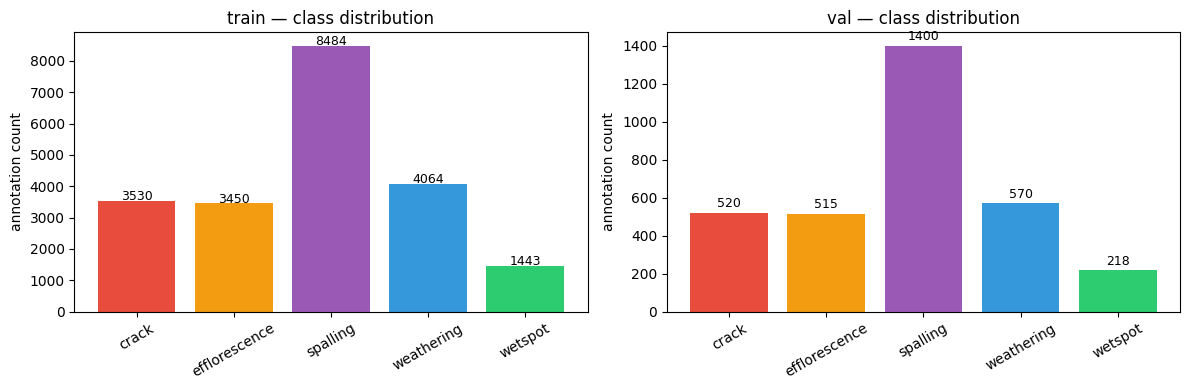

In [5]:
import collections
import matplotlib.pyplot as plt

CLASS_NAMES = ['crack', 'efflorescence', 'spalling', 'weathering', 'wetspot']
COLORS      = ['#e74c3c', '#f39c12', '#9b59b6', '#3498db', '#2ecc71']
YOLO_DIR    = DATA_DIR / 'dacl10k_yolo'

split_counts = {}
for split in ['train', 'val']:
    lbl_dir = YOLO_DIR / 'labels' / split
    counts = collections.Counter()
    for lbl_file in lbl_dir.glob('*.txt'):
        for line in lbl_file.read_text().strip().splitlines():
            if line:
                counts[int(line.split()[0])] += 1
    split_counts[split] = counts
    print(f'{split}: {len(list(lbl_dir.glob("*.txt")))} images, {sum(counts.values())} boxes')
    for i, name in enumerate(CLASS_NAMES):
        print(f'  {name:>15}: {counts[i]:>5}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, split in zip(axes, ['train', 'val']):
    vals = [split_counts[split][i] for i in range(len(CLASS_NAMES))]
    ax.bar(CLASS_NAMES, vals, color=COLORS)
    ax.set_title(f'{split} — class distribution')
    ax.set_ylabel('annotation count')
    ax.tick_params(axis='x', rotation=30)
    for bar, v in zip(ax.patches, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                str(v), ha='center', fontsize=9)
plt.tight_layout()
plt.savefig(OUT_DIR / 'class_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

## 3. Sample Annotation Grid

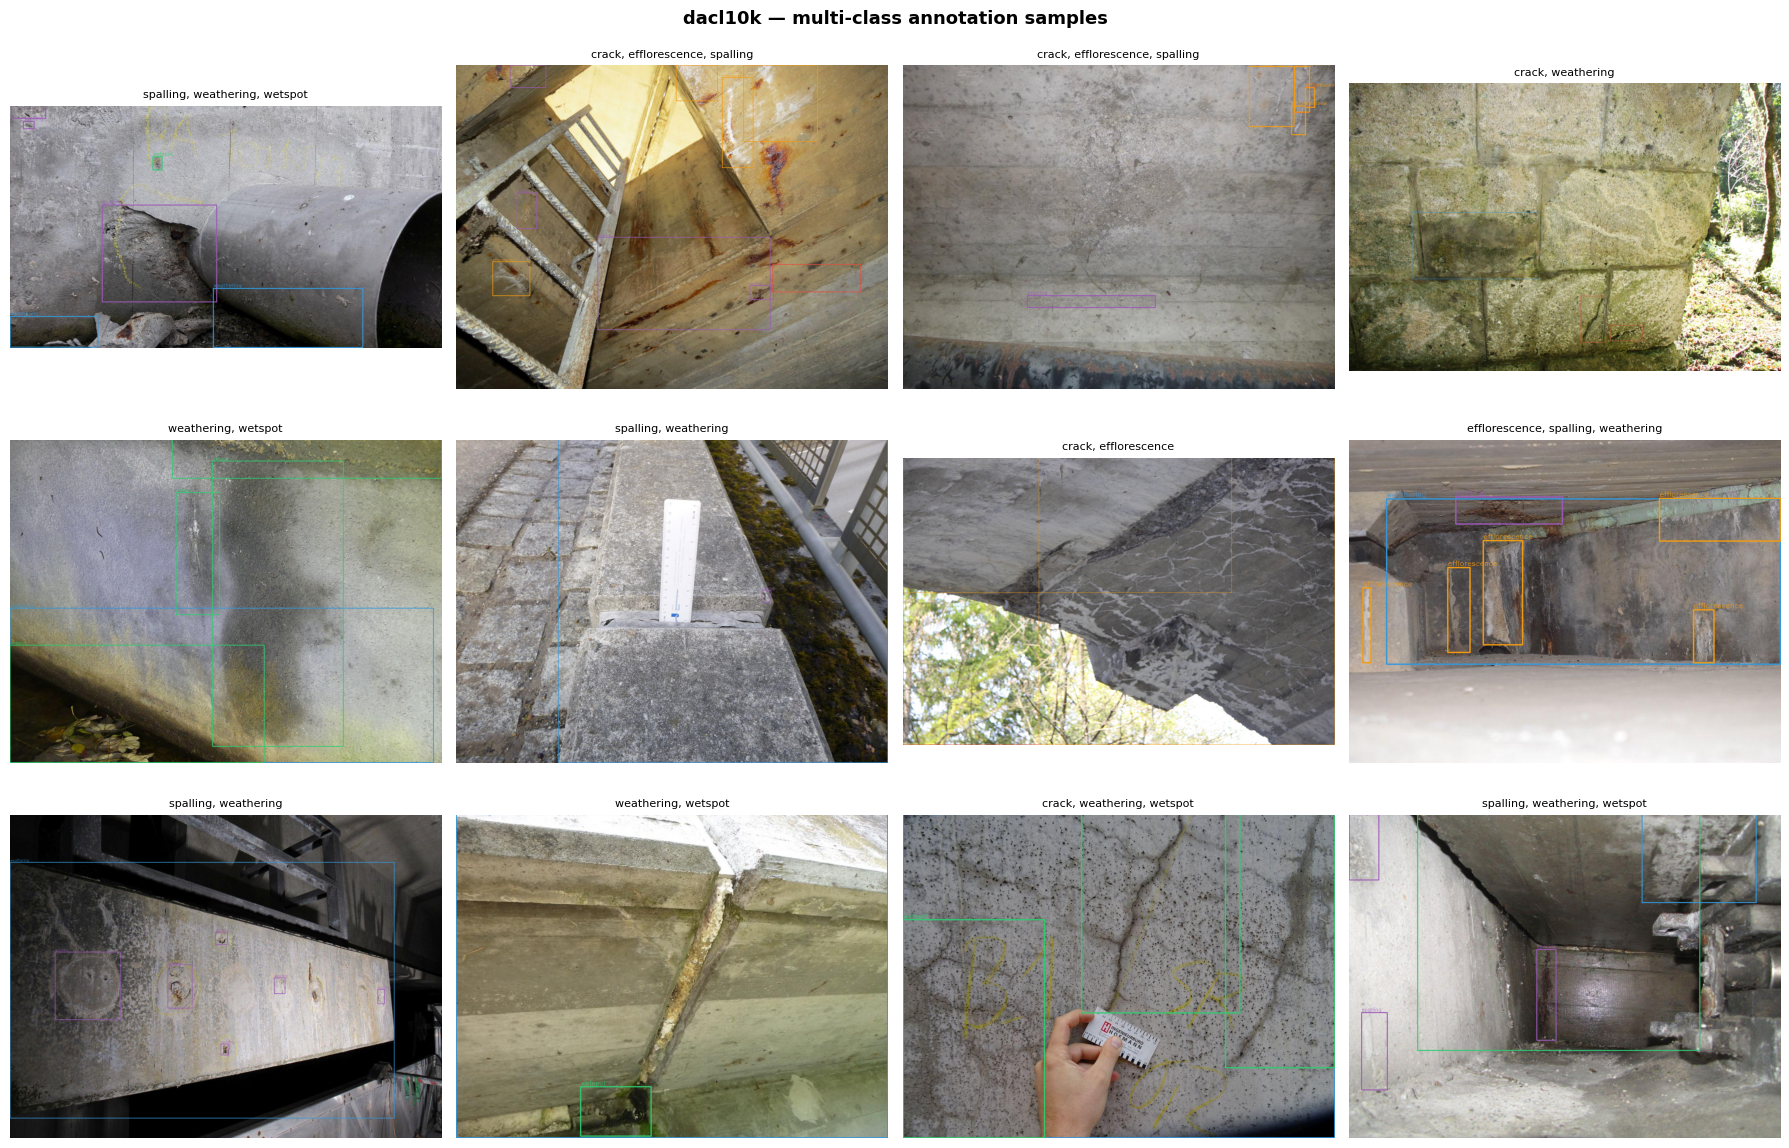

In [6]:
import cv2, random
import numpy as np

COLOR_MAP = {
    0: (231, 76,  60),
    1: (243, 156, 18),
    2: (155, 89,  182),
    3: (52,  152, 219),
    4: (46,  204, 113),
}

def draw_boxes(img_path, lbl_path):
    img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    for line in Path(lbl_path).read_text().strip().splitlines():
        if not line: continue
        cls, cx, cy, bw, bh = map(float, line.split())
        cls = int(cls)
        x1 = int((cx - bw/2) * w); y1 = int((cy - bh/2) * h)
        x2 = int((cx + bw/2) * w); y2 = int((cy + bh/2) * h)
        cv2.rectangle(img, (x1,y1), (x2,y2), COLOR_MAP[cls], 2)
        cv2.putText(img, CLASS_NAMES[cls], (x1, max(y1-4,0)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, COLOR_MAP[cls], 1)
    return img

img_dir = YOLO_DIR / 'images' / 'train'
lbl_dir = YOLO_DIR / 'labels' / 'train'

rich = [lf for lf in lbl_dir.glob('*.txt')
        if len({int(l.split()[0]) for l in lf.read_text().strip().splitlines() if l}) >= 2]

random.seed(42)
samples = random.sample(rich, min(12, len(rich)))

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
for ax, lf in zip(axes.flat, samples):
    vis = draw_boxes(img_dir / (lf.stem + '.jpg'), lf)
    ax.imshow(vis); ax.axis('off')
    classes = {CLASS_NAMES[int(l.split()[0])] for l in lf.read_text().strip().splitlines() if l}
    ax.set_title(', '.join(sorted(classes)), fontsize=8)
for ax in axes.flat[len(samples):]:
    ax.axis('off')
plt.suptitle('dacl10k — multi-class annotation samples', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'sample_annotations.png', dpi=120, bbox_inches='tight')
plt.show()

## 4. Load Base Model

Uses the crack detector from Drive if available, otherwise falls back to `yolov8s.pt` (COCO pretrained).

In [7]:
from ultralytics import YOLO
import torch

crack_detector = DRIVE_DIR / 'detector_best.pt'

if crack_detector.exists():
    BASE_MODEL = str(crack_detector)
    print(f'Using crack detector from Drive: {crack_detector}')
else:
    BASE_MODEL = 'yolov8s.pt'
    print('crack detector not found in Drive — using yolov8s.pt (COCO pretrained)')
    print(f'To use crack detector: upload detector_best.pt to {DRIVE_DIR}')

model = YOLO(BASE_MODEL)
print(f'Base model nc={model.model.nc}, task={model.task}')
print(f'CUDA available: {torch.cuda.is_available()}')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
crack detector not found in Drive — using yolov8s.pt (COCO pretrained)
To use crack detector: upload detector_best.pt to /content/drive/MyDrive/HeritagePreservation
Base model nc=80, task=detect
CUDA available: True


## 5. Train

In [8]:
import torch
torch.manual_seed(42)

DATA_YAML = YOLO_DIR / 'data.yaml'

results = model.train(
    data         = str(DATA_YAML),
    epochs       = 50,
    imgsz        = 640,
    batch        = 16,
    device       = 0,
    workers      = 4,
    project      = str(OUT_DIR),
    name         = 'train',
    exist_ok     = True,
    patience     = 15,
    save         = True,
    plots        = True,
    seed         = 42,
    amp          = True,
    lr0          = 0.005,
    lrf          = 0.01,
    warmup_epochs= 3,
    freeze       = 10,
    close_mosaic = 10,
    mosaic       = 1.0,
    degrees      = 10.0,
    fliplr       = 0.5,
    scale        = 0.3,
)

print(f"mAP@50   : {results.results_dict.get('metrics/mAP50(B)', 'N/A')}")
print(f"mAP@50-95: {results.results_dict.get('metrics/mAP50-95(B)', 'N/A')}")

Ultralytics 8.4.53 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data/dacl10k_yolo/data.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=1

## 6. Save Weights to Drive

In [9]:
import shutil

best_pt = OUT_DIR / 'train' / 'weights' / 'best.pt'
dst     = DRIVE_DIR / 'dacl10k_best.pt'

shutil.copy2(best_pt, dst)
print(f'Saved → {dst}')

Saved → /content/drive/MyDrive/HeritagePreservation/dacl10k_best.pt


## 7. Evaluate Best Checkpoint

In [10]:
best_model  = YOLO(str(best_pt))
val_results = best_model.val(
    data    = str(DATA_YAML),
    split   = 'val',
    device  = 0,
    imgsz   = 640,
    verbose = True,
)

print('\n=== Per-class mAP@50 ===')
for i, name in enumerate(CLASS_NAMES):
    ap = val_results.box.ap50[i] if hasattr(val_results.box, 'ap50') else float('nan')
    print(f'  {name:>15}: {ap:.4f}')

print(f'\nmAP@50    : {val_results.box.map50:.4f}')
print(f'mAP@50-95 : {val_results.box.map:.4f}')
print(f'Precision : {val_results.box.mp:.4f}')
print(f'Recall    : {val_results.box.mr:.4f}')

Ultralytics 8.4.53 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,127,519 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2946.6±1035.5 MB/s, size: 990.4 KB)
val: Scanning /content/data/dacl10k_yolo/labels/val.cache... 975 images, 197 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 975/975 371.8Mit/s 0.0s
val: /content/data/dacl10k_yolo/images/val/dacl10k_v2_validation_0545.jpg: corrupt JPEG restored and saved
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 61/61 2.1it/s 29.1s
                   all        975       3223      0.245      0.185      0.135     0.0627
                 crack        286        520      0.303      0.183      0.127     0.0484
         efflorescence        206        515      0.211      0.146      0.093     0.0409
              spalling        477       1400      0.298      0.189      0.162     0.0807
            wea

## 8. Training Curves

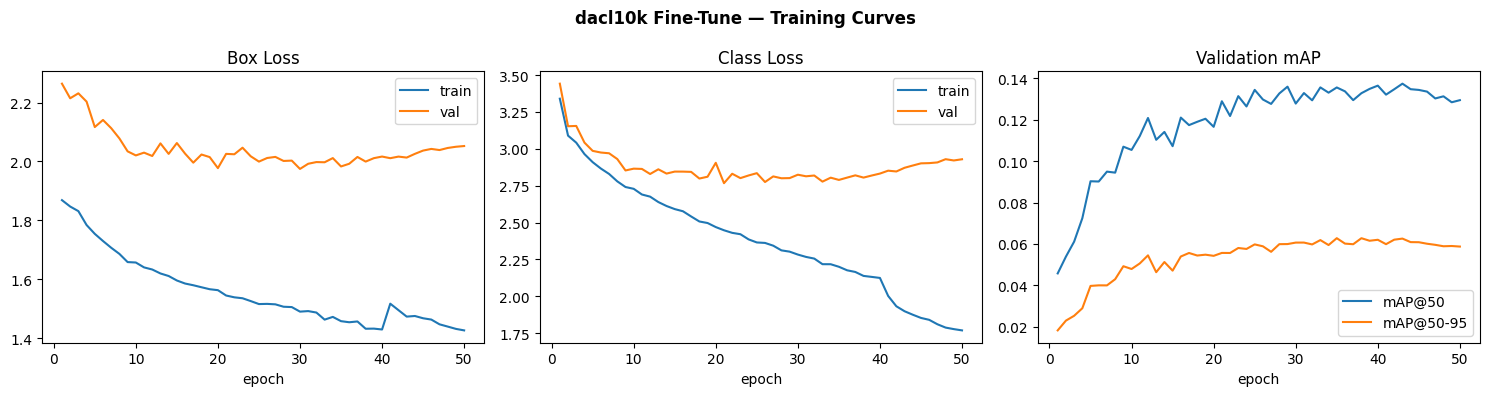

In [11]:
import pandas as pd

df = pd.read_csv(OUT_DIR / 'train' / 'results.csv')
df.columns = df.columns.str.strip()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(df['epoch'], df['train/box_loss'], label='train')
axes[0].plot(df['epoch'], df['val/box_loss'],   label='val')
axes[0].set_title('Box Loss'); axes[0].legend()

axes[1].plot(df['epoch'], df['train/cls_loss'], label='train')
axes[1].plot(df['epoch'], df['val/cls_loss'],   label='val')
axes[1].set_title('Class Loss'); axes[1].legend()

axes[2].plot(df['epoch'], df['metrics/mAP50(B)'],    label='mAP@50')
axes[2].plot(df['epoch'], df['metrics/mAP50-95(B)'], label='mAP@50-95')
axes[2].set_title('Validation mAP'); axes[2].legend()

for ax in axes: ax.set_xlabel('epoch')
plt.suptitle('dacl10k Fine-Tune — Training Curves', fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'training_curves.png', dpi=120, bbox_inches='tight')
plt.show()

## 9. Inference on Heritage Samples

Upload `samples/` from the project to Drive under `HeritagePreservation/samples/`.

In [12]:
samples_dir = DRIVE_DIR / 'samples'
sample_imgs = sorted(samples_dir.glob('*.jpg'))[:8] if samples_dir.exists() else []

if not sample_imgs:
    print(f'No samples found in {samples_dir} — skipping')
else:
    preds = best_model.predict(
        source  = [str(p) for p in sample_imgs],
        imgsz   = 640,
        conf    = 0.25,
        device  = 0,
        verbose = False,
    )
    n = len(preds)
    cols = 4; rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(18, 4.5 * rows))
    for ax, r in zip(axes.flat, preds):
        ax.imshow(r.plot()[..., ::-1]); ax.axis('off')
        ax.set_title(Path(r.path).stem, fontsize=8)
    for ax in axes.flat[len(preds):]: ax.axis('off')
    plt.suptitle('Multi-Class Detector — Heritage Sample Inference', fontweight='bold')
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'heritage_inference.png', dpi=120, bbox_inches='tight')
    plt.show()

No samples found in /content/drive/MyDrive/HeritagePreservation/samples — skipping


## 10. Summary

| | Single-class detector | Multi-class detector |
|---|---|---|
| Classes | 1 (`crack`) | 5 (`crack`, `efflorescence`, `spalling`, `weathering`, `wetspot`) |
| Training data | OmniCrack30k | dacl10k (~7k images, ~21k boxes) |
| mAP@50 val | 96.7% | *see cell 7* |

Multi-class model enables richer heritage building damage analysis — mapping each detected region to a specific deterioration type.